In [43]:
import pandas as pd
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [44]:
# Base directory where all CSVs are saved
base_dir = Path("../outputs/csv")


In [45]:
perf_files = sorted(base_dir.glob("wifi-random-*-perf.csv"))

if not perf_files:
    raise FileNotFoundError("No perf.csv files found")

In [46]:
rssi_files = sorted(base_dir.glob("wifi-random-*-rssi.csv"))
if not rssi_files:
    raise FileNotFoundError("No rssi.csv files found")

In [47]:
modulation_files = sorted(base_dir.glob("wifi-random-*-modulation.csv"))
if not modulation_files:
    raise FileNotFoundError("No modulation.csv files found")

In [48]:
def load_and_combine_datetime(file_path):
    df = pd.read_csv(file_path)

    # Check for required columns
    required_cols = ['RunDateTime', 'time_s']
    if all(col in df.columns for col in required_cols):
        df['RunDateTime'] = pd.to_datetime(df['RunDateTime'], errors='coerce')
        df['time_delta'] = pd.to_timedelta(df['time_s'], unit='s')
        df['SimDateTime'] = df['RunDateTime'] + df['time_delta']
    else:
        missing = [col for col in required_cols if col not in df.columns]
        print(f"⚠️ Missing columns in {file_path.name}: {missing}")

    return df



In [49]:
nodedensity_files = sorted(base_dir.glob("wifi-random-*-nodedensity.csv"))
if not nodedensity_files:
    raise FileNotFoundError("No nodedensity.csv files found")

In [50]:
# Combine perf files
perf_dfs = []
for f in perf_files:
    ts = f.stem.replace("wifi-random-", "").replace("-perf", "")
    df = pd.read_csv(f)
    df["Run_Timestamp"] = ts
    perf_dfs.append(df)
perf_df = pd.concat(perf_dfs, ignore_index=True)

print(f"✅ Loaded {len(perf_files)} perf files")

✅ Loaded 1 perf files


In [51]:
rssi_dfs = []
for f in rssi_files:
    # ts = f.stem.replace("wifi-random-", "").replace("-rssi", "")
    df = load_and_combine_datetime(f)
    # df["Run_Timestamp"] = ts
    rssi_dfs.append(df)

rssi_df = pd.concat(rssi_dfs, ignore_index=True)
print(f"✅ Loaded {len(rssi_files)} rssi files")

✅ Loaded 1 rssi files


In [52]:
modulation_dfs = []
for f in modulation_files:
    # ts = f.stem.replace("wifi-random-", "").replace("-modulation", "")
    df = load_and_combine_datetime(f)
    # df["Run_Timestamp"] = ts
    modulation_dfs.append(df)
modulation_df = pd.concat(modulation_dfs, ignore_index=True)
print(f"✅ Loaded {len(modulation_files)} modulation files")

✅ Loaded 1 modulation files


In [53]:
nodedensity_dfs = []
for f in nodedensity_files:
    ts = f.stem.replace("wifi-random-", "").replace("-nodedensity", "")
    df = pd.read_csv(f)
    df["Run_Timestamp"] = ts
    nodedensity_dfs.append(df)
nodedensity_df = pd.concat(nodedensity_dfs, ignore_index=True)
print(f"✅ Loaded {len(nodedensity_files)} nodedensity files")

✅ Loaded 1 nodedensity files


In [54]:
def load_simulation_files(base_dir: str, pattern: str):
    """
    Load and label multiple CSV files with runtime and seed metadata.
    """
    base = Path(base_dir)
    files = glob.glob(str(base / pattern))
    dfs = []

    for f in files:
        df = pd.read_csv(f)
        parts = Path(f).stem.split("-")
        runtime = "-".join(parts[2:4])  # e.g. 26-Oct-2025_01-16
        seed = [p for p in parts if p.startswith("seed")][0].replace("seed", "")
        df["RunDateTime"] = runtime
        df["RandSeed"] = int(seed)
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)
    print(f"✅ Loaded {len(dfs)} files ({len(combined):,} total rows).")
    return combined


In [55]:
def plot_by_time(df, metric: str, group_by="RandSeed", title=None):
    """
    Plot a metric versus simulation time for different random seeds or runs.
    """
    if "SimDateTime" not in df.columns:
        print("❌ Missing 'SimDateTime' column — please run merge_simulation_data first.")
        return
    
    plt.figure(figsize=(9,5))
    for key, grp in df.groupby(group_by):
        plt.plot(grp["SimDateTime"], grp[metric], label=f"{group_by}={key}")
    plt.xlabel("Simulation Time")
    plt.ylabel(metric)
    plt.title(title or f"{metric} over Simulation Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [56]:
def plot_by_time(df, metric: str, group_by="RandSeed", title=None):
    """
    Plot a metric versus simulation time for different random seeds or runs.
    """
    if "SimDateTime" not in df.columns:
        print("❌ Missing 'SimDateTime' column — please run merge_simulation_data first.")
        return
    
    plt.figure(figsize=(9,5))
    for key, grp in df.groupby(group_by):
        plt.plot(grp["SimDateTime"], grp[metric], label=f"{group_by}={key}")
    plt.xlabel("Simulation Time")
    plt.ylabel(metric)
    plt.title(title or f"{metric} over Simulation Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [57]:
def plot_by_density(df, metric: str, agg="mean", title=None):
    """
    Plot average (or median) performance metric versus node density.
    """
    if "NodeDensity" not in df.columns:
        print("❌ Column 'NodeDensity' not found in DataFrame.")
        return
    
    agg_func = np.mean if agg == "mean" else np.median
    summary = df.groupby("NodeDensity")[metric].agg(agg_func).reset_index()
    
    plt.figure(figsize=(7,5))
    plt.plot(summary["NodeDensity"], summary[metric], marker="o")
    plt.xlabel("Node Density")
    plt.ylabel(metric)
    plt.title(title or f"{metric} vs Node Density ({agg.capitalize()})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return summary

In [58]:
def analyze_perf(perf_df):
    """Plots throughput, latency, jitter, and packet loss from the performance dataset."""
    print(f"📘 perf_df: {perf_df.shape[0]} rows, {perf_df.shape[1]} columns")

    # --- Throughput over Simulation Time ---
    if "FlowID" in perf_df.columns and "Throughput(Mbps)" in perf_df.columns:
        plt.figure(figsize=(8, 5))
        plt.barh(perf_df['FlowID'], perf_df['Throughput(Mbps)'], label='Throughput', color='skyblue')
        # plt.barh(perf_df['FlowID'], perf_df['Jitter_avg(ms)'], label='Jitter_avg(ms)', color='yellow')
        # plt.barh(perf_df['FlowID'], perf_df['Latency_avg(ms)'], label='Latency_avg(ms)', color='red')
        # plt.legend()
        plt.ylabel('FlowID')
        plt.xlabel('Throughput(Mbps)')
        plt.title('Bar Plot of Throughput by FlowID')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    if "FlowID" in perf_df.columns and "Jitter_avg(ms)" in perf_df.columns:
        plt.figure(figsize=(8, 5))
        plt.barh(perf_df['FlowID'], perf_df['Jitter_avg(ms)'], label='Jitter_avg(ms)', color='yellow')
        # plt.barh(perf_df['FlowID'], perf_df['Latency_avg(ms)'], label='Latency_avg(ms)', color='red')
        plt.legend()
        plt.ylabel('FlowID')
        plt.xlabel('Jitter_avg(ms)')
        plt.title('Bar Plot of Jitter_avg(ms) by FlowID')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    if "FlowID" in perf_df.columns and "Latency_avg(ms)" in perf_df.columns:
        plt.figure(figsize=(8, 5))
        plt.barh(perf_df['FlowID'], perf_df['Latency_avg(ms)'], label='Latency_avg(ms)', color='red')
        plt.legend()
        plt.ylabel('FlowID')
        plt.xlabel('Latency_avg(ms)')
        plt.title('Bar Plot of Latency_avg(ms) by FlowID')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    # --- Latency and Jitter Trends ---
    if "Latency_avg(ms)" in perf_df.columns and "Jitter_avg(ms)" in perf_df.columns:
        plt.figure(figsize=(8,5))
        plt.bar(perf_df["Duration_s"], perf_df["Latency_avg(ms)"], label="Latency (ms)", color="tab:red")
        plt.bar(perf_df["Duration_s"], perf_df["Jitter_avg(ms)"], label="Jitter (ms)", color="tab:green")
        plt.xlabel("Duration Time (s)")
        plt.ylabel("Delay Metrics (ms)")
        plt.title("Bar Plot of Latency and Jitter by Duration Time")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    if "Latency_avg(ms)" in perf_df.columns and "PacketLoss(%)" in perf_df.columns:
        plt.figure(figsize=(8,5))
        plt.bar(perf_df["Latency_avg(ms)"], perf_df["PacketLoss(%)"], label="Packet Loss (%)", color="tab:red")
        # plt.bar(perf_df["Duration_s"], perf_df["Jitter_avg(ms)"], label="Jitter (ms)", color="tab:green")
        plt.xlabel("Latency (ms)")
        plt.ylabel("Packet Loss (%)")
        plt.title("Bar Plot of Latency and Packet Loss")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # --- Packet Loss Distribution ---
    if "PacketLoss(%)" in perf_df.columns:
        plt.figure(figsize=(7,4))
        plt.hist(perf_df["PacketLoss(%)"], bins=20, color="tab:orange", edgecolor="black")
        plt.xlabel("Packet Loss (%)")
        plt.ylabel("Count")
        plt.title("Distribution of Packet Loss")
        plt.tight_layout()
        plt.show()

In [59]:
def analyze_rssi(rssi_df):
    """Plots signal, noise, and SNR from the RSSI dataset."""
    print(f"📘 rssi_df: {rssi_df.shape[0]} rows, {rssi_df.shape[1]} columns")

    # --- Signal vs Time ---
    if "time_s" in rssi_df.columns and "signal_dBm" in rssi_df.columns:
        plt.figure(figsize=(8,5))
        plt.plot(rssi_df["time_s"], rssi_df["signal_dBm"], label="Signal (dBm)", color="tab:blue")
        if "noise_dBm" in rssi_df.columns:
            plt.plot(rssi_df["time_s"], rssi_df["noise_dBm"], label="Noise (dBm)", color="tab:red")
        plt.xlabel("Simulation Time (s)")
        plt.ylabel("Power (dBm)")
        plt.title("Signal and Noise over Time")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # --- SNR Distribution ---
    if "SNR_dB" in rssi_df.columns:
        plt.figure(figsize=(7,4))
        plt.hist(rssi_df["SNR_dB"], bins=25, color="tab:green", edgecolor="black")
        plt.xlabel("SNR (dB)")
        plt.ylabel("Frequency")
        plt.title("Distribution of Signal-to-Noise Ratio (SNR)")
        plt.tight_layout()
        plt.show()

In [60]:
def analyze_nodedensity(nodedensity_df):
    """Plots throughput vs node density if both metrics exist."""
    print(f"📘 nodedensity_df: {nodedensity_df.shape[0]} rows, {nodedensity_df.shape[1]} columns")

    if "NodeDensity" in nodedensity_df.columns and "TotalThroughput(Mbps)" in nodedensity_df.columns:
        plt.figure(figsize=(7,5))
        plt.plot(nodedensity_df["NodeDensity"], nodedensity_df["TotalThroughput(Mbps)"], marker="o")
        plt.xlabel("Node Density")
        plt.ylabel("Throughput (Mbps)")
        plt.title("Throughput vs Node Density")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [61]:
def analyze_modulation(modulation_df):
    """
    Generate thesis-level plots from modulation.csv:
      - SNR vs Modulation
      - Signal vs Channel Frequency
      - Noise vs Channel Frequency
      - SNR Histogram
    """
    print(f"📘 modulation_df: {modulation_df.shape[0]} rows, {modulation_df.shape[1]} columns")

    # Clean invalid or missing values
    df = modulation_df.copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["SNR_dB", "signal_dBm", "noise_dBm"])
    df = df[df["signal_dBm"] < 0]  # Filter physically meaningful RSSI values

    # ---------- 1️⃣ SNR vs Modulation ----------
    if {"Modulation", "SNR_dB"}.issubset(df.columns):
        plt.figure(figsize=(7,5))
        sns.boxplot(x="Modulation", y="SNR_dB", data=df, color="skyblue")
        plt.title("SNR Distribution across Modulation Schemes")
        plt.xlabel("Modulation Scheme")
        plt.ylabel("SNR (dB)")
        plt.grid(True, axis="y", linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    # ---------- 2️⃣ Signal Strength vs Channel Frequency ----------
    if {"channel_MHz", "signal_dBm"}.issubset(df.columns):
        plt.figure(figsize=(7,5))
        plt.scatter(df["channel_MHz"], df["signal_dBm"], color="orange", alpha=0.7)
        plt.title("Signal Strength vs Channel Frequency")
        plt.xlabel("Channel Frequency (MHz)")
        plt.ylabel("Signal Strength (dBm)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # ---------- 3️⃣ Noise Power vs Channel Frequency ----------
    if {"channel_MHz", "noise_dBm"}.issubset(df.columns):
        plt.figure(figsize=(7,5))
        plt.scatter(df["channel_MHz"], df["noise_dBm"], color="tab:gray", alpha=0.7)
        plt.title("Noise Power vs Channel Frequency")
        plt.xlabel("Channel Frequency (MHz)")
        plt.ylabel("Noise Power (dBm)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # ---------- 4️⃣ SNR Histogram ----------
    if "SNR_dB" in df.columns:
        plt.figure(figsize=(7,4))
        plt.hist(df["SNR_dB"], bins=25, color="tab:green", edgecolor="black", alpha=0.8)
        plt.xlabel("SNR (dB)")
        plt.ylabel("Count")
        plt.title("Distribution of Signal-to-Noise Ratio")
        plt.tight_layout()
        plt.show()

In [62]:
perf_df.head(5)

,FlowID,Source,Destination,Throughput(Mbps),Latency_avg(ms),Jitter_avg(ms),PacketLoss(%),Duration_s,RandSeed,RunDateTime,Run_Timestamp
0,1,10.1.3.1,10.1.3.31,0.000000,0.0000,0.0000,100.0000,0.00000,12345,26-Oct-2025_12-50,26-Oct-2025_12-50-seed12345
1,2,10.1.3.2,10.1.3.31,0.000000,0.0000,0.0000,100.0000,0.00000,12345,26-Oct-2025_12-50,26-Oct-2025_12-50-seed12345
2,3,10.1.3.3,10.1.3.31,0.000000,0.0000,0.0000,100.0000,0.00000,12345,26-Oct-2025_12-50,26-Oct-2025_12-50-seed12345
3,4,10.1.3.4,10.1.3.31,0.000000,0.0000,0.0000,100.0000,0.00000,12345,26-Oct-2025_12-50,26-Oct-2025_12-50-seed12345
4,5,10.1.3.5,10.1.3.31,0.361474,25.3562,33.8456,90.5357,6.16984,12345,26-Oct-2025_12-50,26-Oct-2025_12-50-seed12345


📘 perf_df: 40 rows, 11 columns


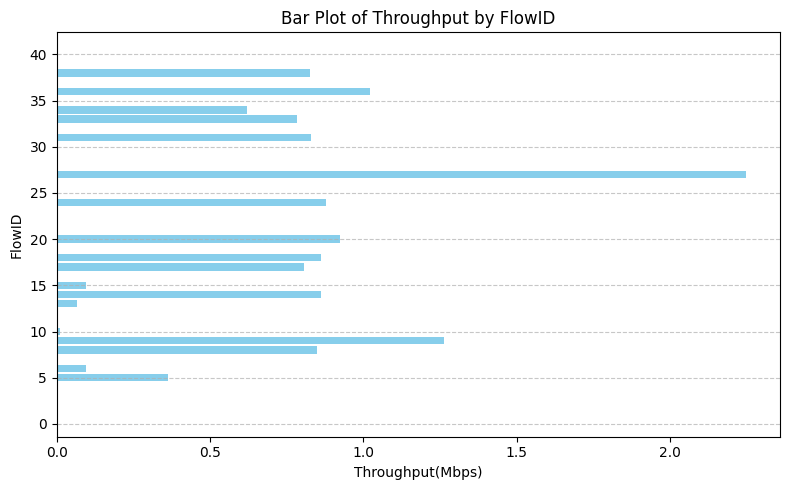

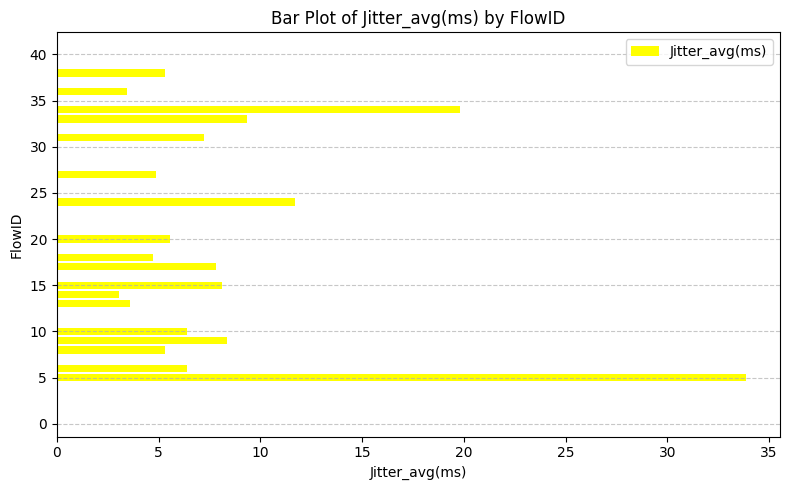

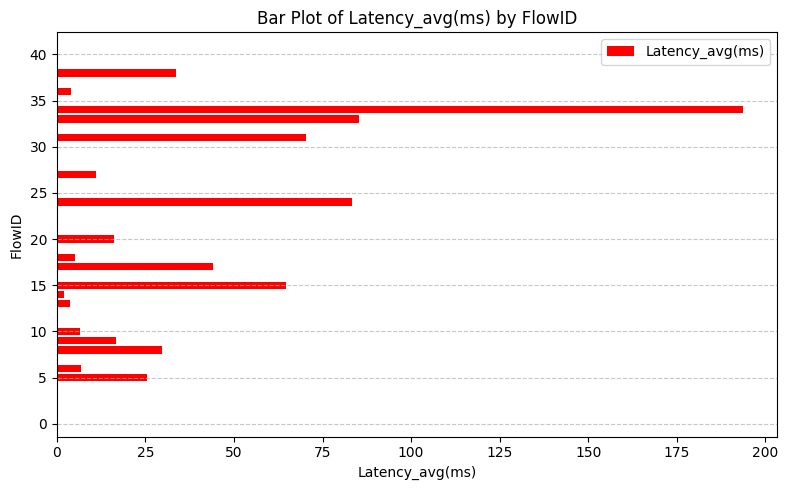

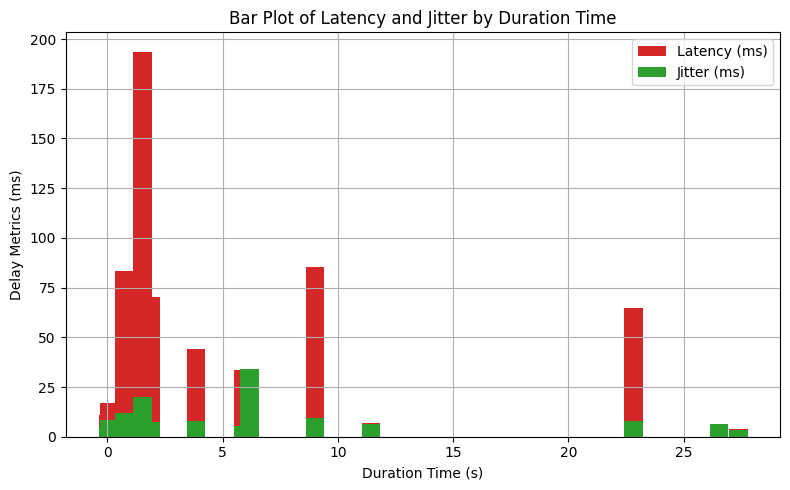

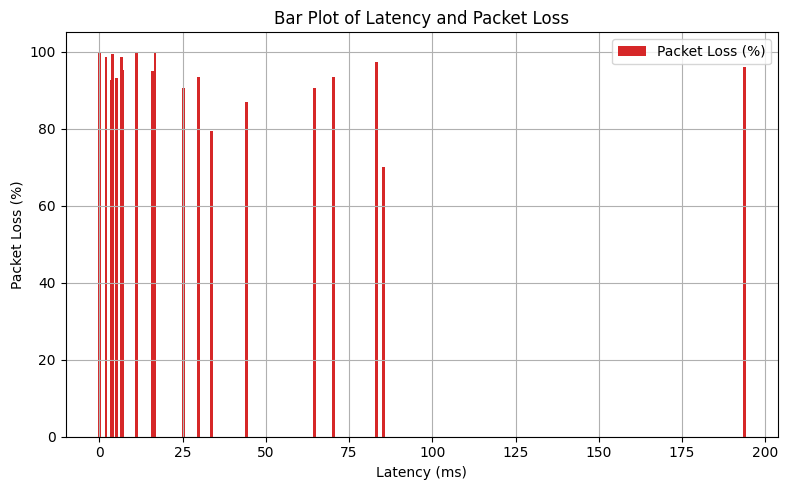

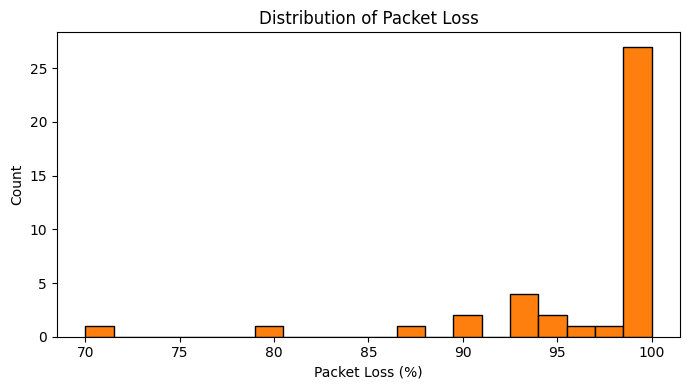

In [63]:
analyze_perf(perf_df)


📘 rssi_df: 41992 rows, 9 columns


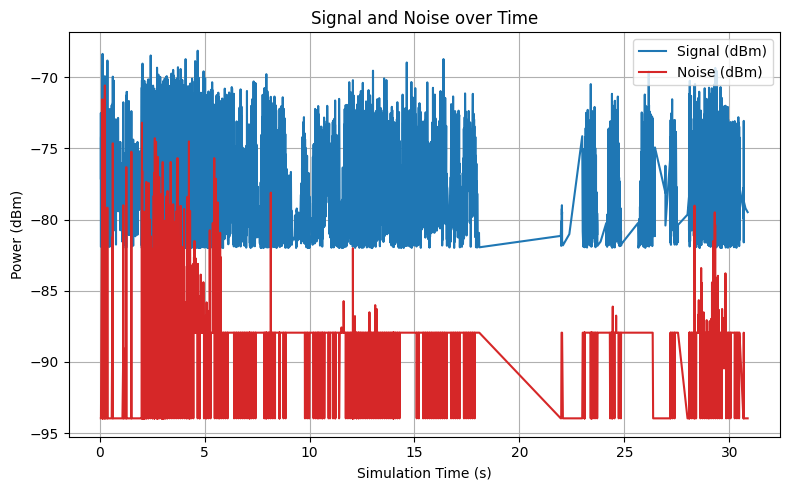

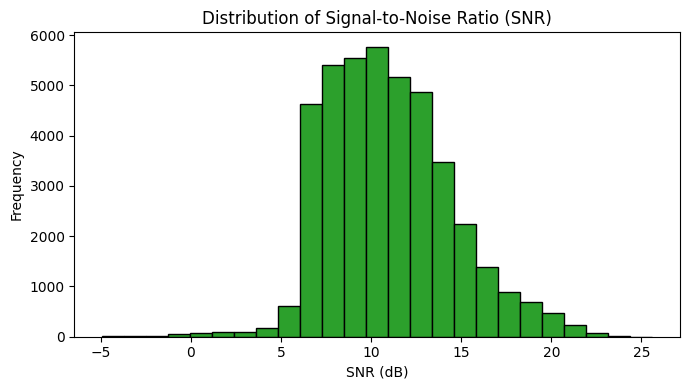

In [64]:
analyze_rssi(rssi_df)


📘 nodedensity_df: 6 rows, 13 columns


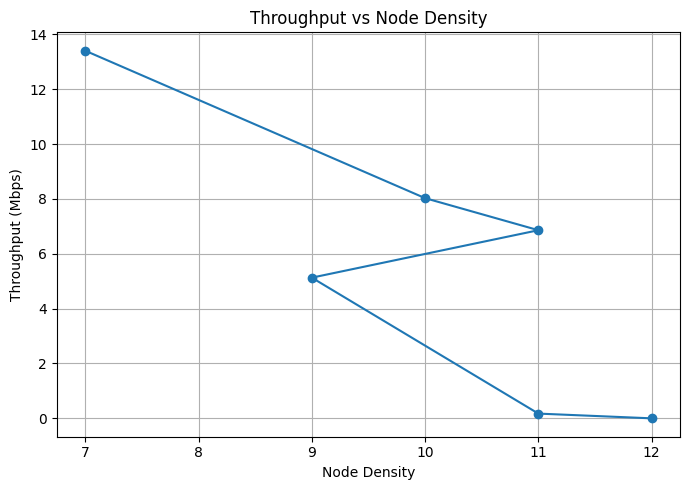

In [65]:
analyze_nodedensity(nodedensity_df)


In [66]:
modulation_df.head(5)

,time_s,channel_MHz,Modulation,ConstellationSize,PhyRate_Mbps,signal_dBm,noise_dBm,SNR_dB,BER,RandSeed,RunDateTime,time_delta,SimDateTime
0,5210,OFDM,2,6.0,-77.102540,-93.965985,16.863445,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT
1,5210,OFDM,2,6.0,-72.502153,-93.965985,21.463832,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT
2,5210,OFDM,2,6.0,-73.761263,-93.965985,20.204723,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT
3,5210,OFDM,2,6.0,-79.613417,-93.965985,14.352568,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT
4,5210,OFDM,2,6.0,-81.601945,-93.965985,12.364040,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT


📘 modulation_df: 41992 rows, 13 columns


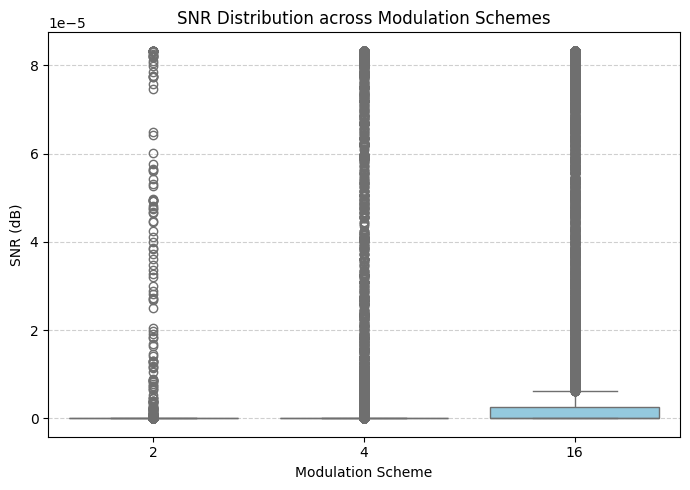

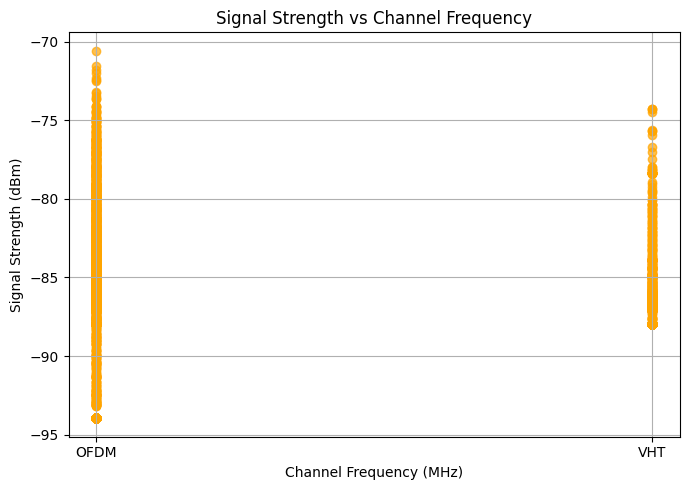

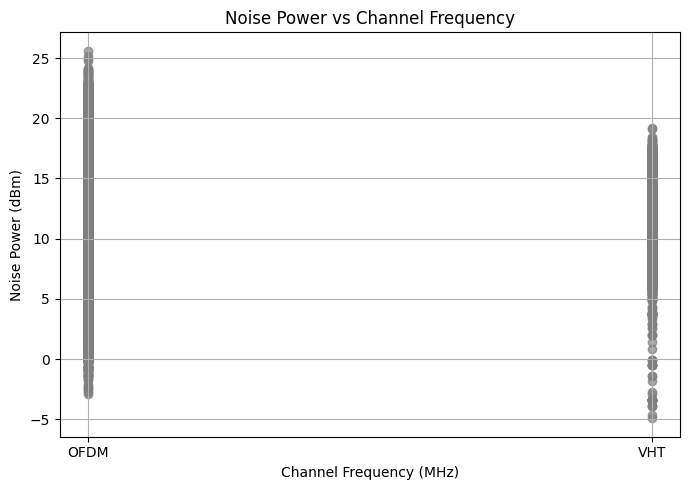

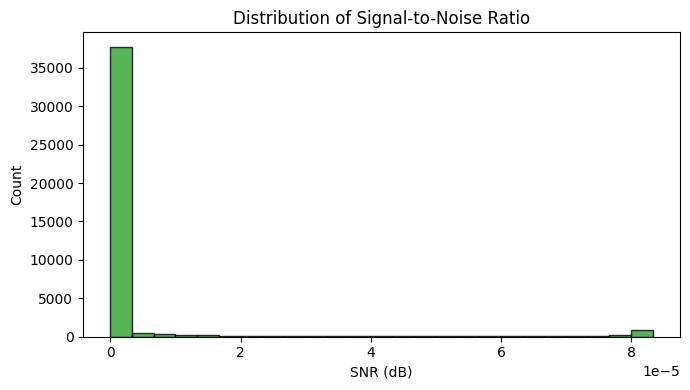

In [67]:
analyze_modulation(modulation_df)

In [68]:
def analyze_wifi_performance(perf_df, rssi_df, nd_df, mod_df=None):
    """
    Perform performance analysis and discussion for NS-3 Wi-Fi simulation.
    Generates plots and prints interpretive statements.
    
    Parameters:
        perf_df : DataFrame  # flow-level performance data (-perf.csv)
        rssi_df : DataFrame  # physical-layer RSSI/SNR data (-rssi.csv)
        nd_df   : DataFrame  # node density aggregation (-nodedensity.csv)
        mod_df  : DataFrame  # optional modulation data (-modulation.csv)
    """
    print("=== Wi-Fi Performance Analysis ===\n")

    # --- 1. Throughput vs Node Density ---
    if "NodeDensity" in nd_df.columns and "TotalThroughput(Mbps)" in nd_df.columns:
        plt.figure(figsize=(7,5))
        plt.plot(nd_df["NodeDensity"], nd_df["TotalThroughput(Mbps)"],
                 marker="o", color="tab:blue", linewidth=2)
        plt.title("Throughput vs Node Density")
        plt.xlabel("Node Density (# of Active Stations)")
        plt.ylabel("Total Throughput (Mbps)")
        plt.grid(True)
        plt.show()

    
    # --- 2. RSSI vs Node Density ---
    if "AvgRSSI(dBm)" in nd_df.columns and nd_df["AvgRSSI(dBm)"].abs().sum() > 0:
        plt.figure(figsize=(7,5))
        plt.plot(nd_df["NodeDensity"], nd_df["AvgRSSI(dBm)"],
                 marker="s", color="tab:orange", linewidth=2)
        plt.title("RSSI vs Node Density")
        plt.xlabel("Node Density (# of Active Stations)")
        plt.ylabel("Average RSSI (dBm)")
        plt.grid(True)
        plt.show()

       
    # --- 3. RSSI vs Time (proxy for distance/mobility) ---
    if "time_s" in rssi_df.columns and "signal_dBm" in rssi_df.columns:
        plt.figure(figsize=(7,5))
        plt.scatter(rssi_df["time_s"], rssi_df["signal_dBm"],
                    s=8, color="tab:green", alpha=0.6)
        plt.title("RSSI Variation Over Time (Distance Proxy)")
        plt.xlabel("Simulation Time (s)")
        plt.ylabel("Signal Strength (dBm)")
        plt.grid(True)
        plt.show()

        
    

       
    print("✅ Analysis complete.\n")

=== Wi-Fi Performance Analysis ===



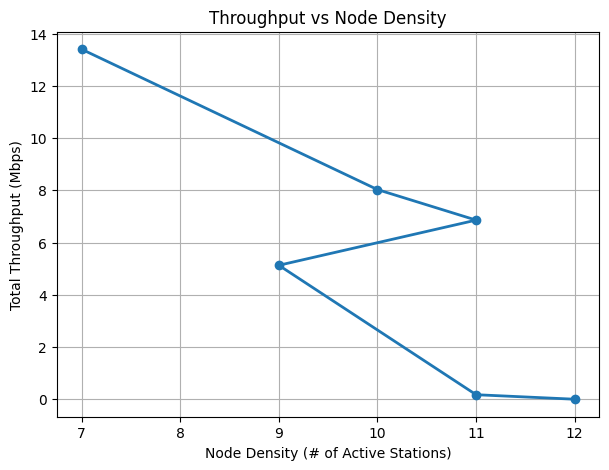

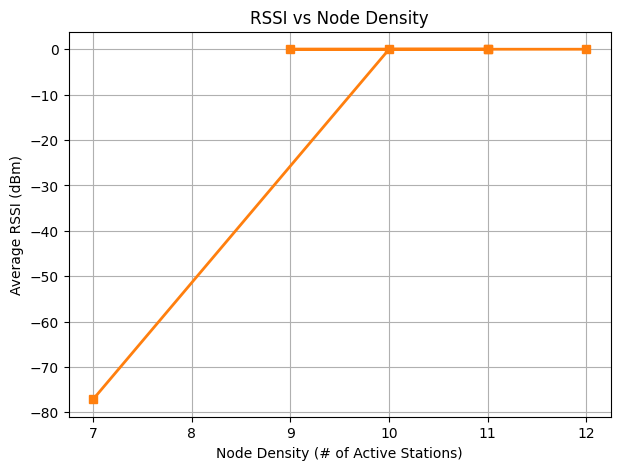

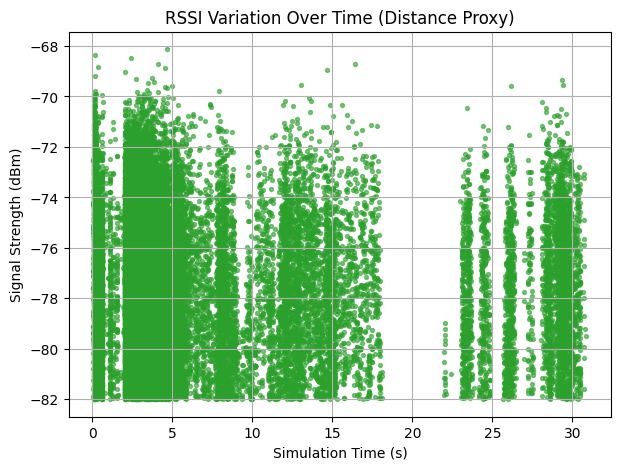

✅ Analysis complete.



In [69]:
analyze_wifi_performance(perf_df, rssi_df, nodedensity_df, modulation_df)

In [70]:
def plot_modulation_radar(mod_df):
    # Aggregate by modulation type
    summary = mod_df.groupby("Modulation").agg({
        "PhyRate_Mbps": "mean",
        "SNR_dB": "mean",
        "signal_dBm": "mean",
        "BER": "mean"
    }).reset_index()

    # Normalize metrics to [0,1] for radar plot (BER inverted)
    df_norm = summary.copy()
    df_norm["BER"] = 1 - (np.log10(df_norm["BER"].replace(0, np.nan).fillna(1e-12)) /
                          np.log10(df_norm["BER"].max()))
    cols = ["PhyRate_Mbps", "SNR_dB", "signal_dBm", "BER"]
    df_norm[cols] = (df_norm[cols] - df_norm[cols].min()) / (df_norm[cols].max() - df_norm[cols].min())

    # Radar chart setup
    categories = cols
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

    for i, row in df_norm.iterrows():
        values = row[cols].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=row["Modulation"])
        ax.fill(angles, values, alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_yticklabels([])
    plt.title("Comparison of PHY Parameters by Modulation Scheme")
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

e:\AIT_Projects\NS3-Project\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\satna\AppData\Local\Temp\ipykernel_21680\2282460321.py:13: RuntimeWarning: invalid value encountered in log10
  np.log10(df_norm["BER"].max()))


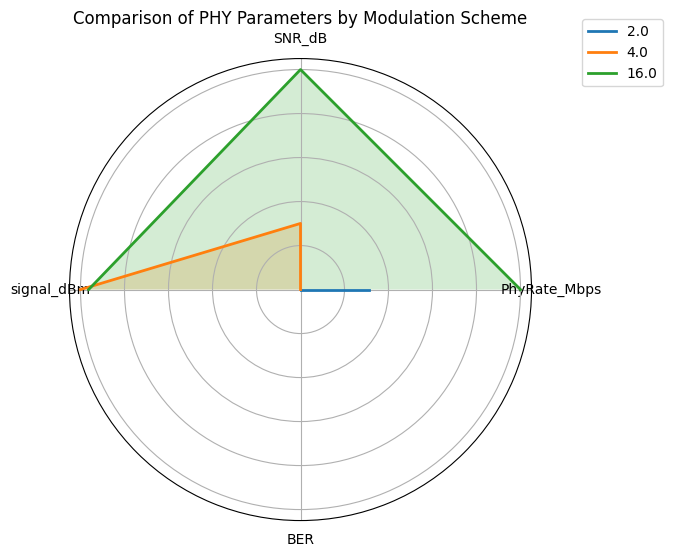

In [71]:
plot_modulation_radar(modulation_df)

In [72]:
def plot_interference_analysis(modulation_df, perf_df=None):
    """
    Visualize and quantify interference using available modulation & performance data.
    Computes: Interference_dBm = signal_dBm - SNR_dB
    Plots:
      - Noise over time
      - Signal vs Noise
      - Interference power over time
      - Throughput vs SNR (if perf_df available)
      - Average noise per channel
    """
    df = modulation_df.copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["signal_dBm", "noise_dBm", "SNR_dB"])
    df = df[df["signal_dBm"] < 0]  # filter physically meaningful RSSI

    # ---------- 🧮 Compute Interference Power ----------
    df["Interference_dBm"] = df["signal_dBm"] - df["SNR_dB"]

    print(f"📘 modulation_df after processing: {df.shape[0]} valid samples")
    print(f"Mean signal: {df['signal_dBm'].mean():.2f} dBm, "
          f"Mean noise: {df['noise_dBm'].mean():.2f} dBm, "
          f"Mean interference: {df['Interference_dBm'].mean():.2f} dBm")

    # ---------- 1️⃣ Noise Power over Time ----------
    if "time_s" in df.columns:
        plt.figure(figsize=(8,5))
        plt.plot(df["time_s"], df["noise_dBm"], label="Noise Power (dBm)", color="gray", alpha=0.7)
        plt.xlabel("Simulation Time (s)")
        plt.ylabel("Noise Power (dBm)")
        plt.title("Noise Power over Time (Interference Indicator)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ---------- 2️⃣ Signal vs Noise Scatter ----------
    plt.figure(figsize=(6,5))
    plt.scatter(df["signal_dBm"], df["noise_dBm"], alpha=0.5, color="tab:red")
    plt.xlabel("Signal Strength (dBm)")
    plt.ylabel("Noise Power (dBm)")
    plt.title("Signal vs Noise Relationship (Interference Mapping)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- 3️⃣ Interference Power over Time ----------
    if "time_s" in df.columns:
        plt.figure(figsize=(8,5))
        plt.plot(df["time_s"], df["Interference_dBm"], color="tab:orange", label="Interference Power (dBm)")
        plt.xlabel("Simulation Time (s)")
        plt.ylabel("Interference Power (dBm)")
        plt.title("Interference Power Variation over Time")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ---------- 4️⃣ Throughput vs SNR (if perf data provided) ----------
    if perf_df is not None and "Throughput(Mbps)" in perf_df.columns:
        merged = perf_df.copy()
        if "SNR_dB" in df.columns and "time_s" in df.columns and "time_s" in merged.columns:
            merged = pd.merge_asof(
                merged.sort_values("time_s"), df.sort_values("time_s"),
                on="time_s", direction="nearest"
            )
            plt.figure(figsize=(7,5))
            sns.scatterplot(x="SNR_dB", y="Throughput(Mbps)", data=merged, alpha=0.7)
            plt.xlabel("SNR (dB)")
            plt.ylabel("Throughput (Mbps)")
            plt.title("Throughput vs SNR (Interference Impact)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    # ---------- 5️⃣ Average Noise per Channel ----------
    if "channel_MHz" in df.columns:
        noise_summary = df.groupby("channel_MHz")["noise_dBm"].mean().reset_index()
        plt.figure(figsize=(7,5))
        plt.bar(noise_summary["channel_MHz"].astype(str), noise_summary["noise_dBm"], color="tab:blue")
        plt.xlabel("Channel Frequency (MHz)")
        plt.ylabel("Avg Noise (dBm)")
        plt.title("Average Noise Power per Channel (Interference Level)")
        plt.grid(True, axis="y", linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    return df

📘 modulation_df after processing: 41992 valid samples
Mean signal: -88.55 dBm, Mean noise: 10.98 dBm, Mean interference: -88.55 dBm


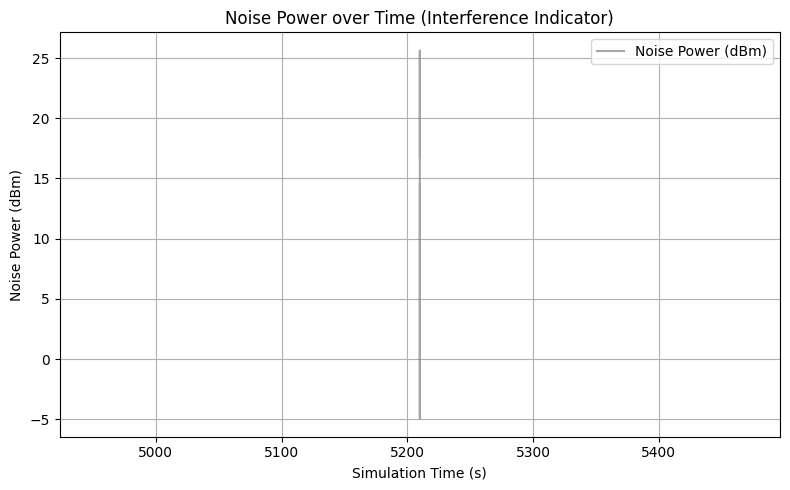

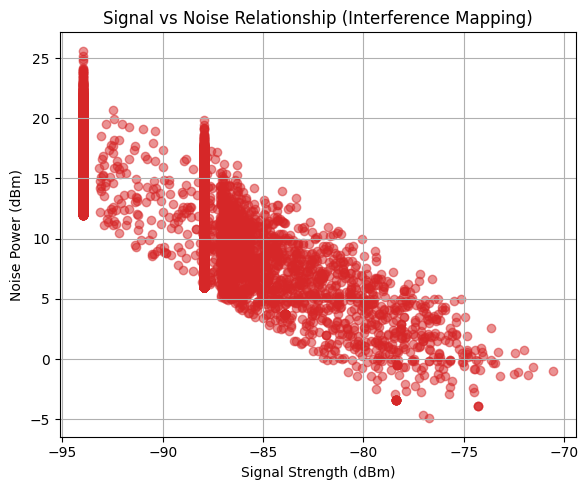

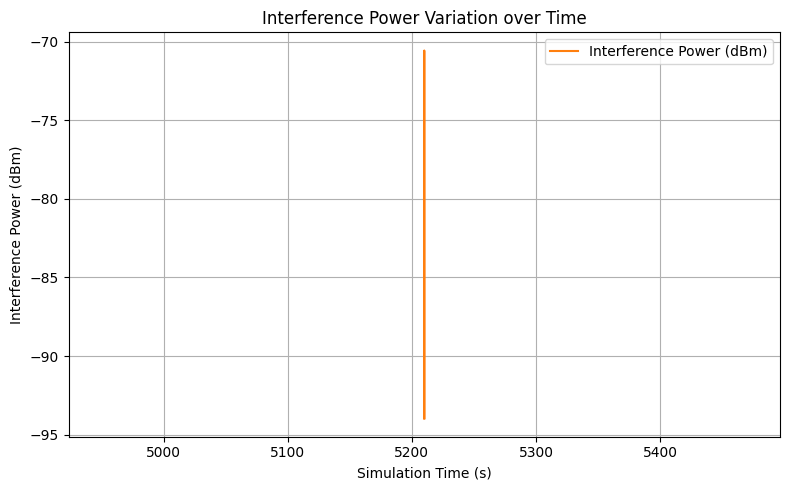

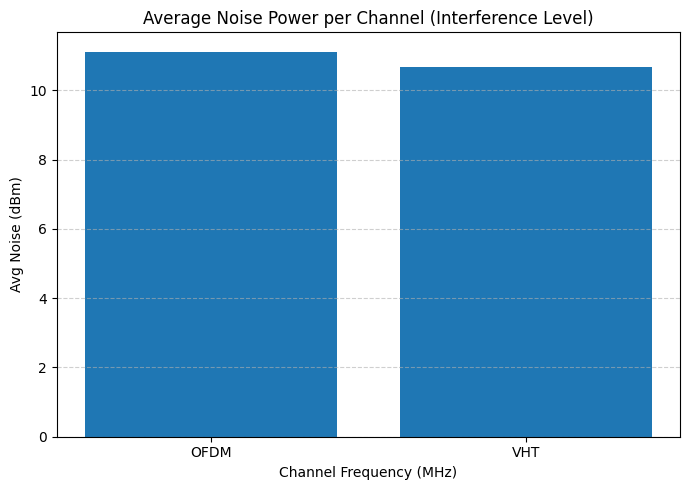

,time_s,channel_MHz,Modulation,ConstellationSize,PhyRate_Mbps,signal_dBm,noise_dBm,SNR_dB,BER,RandSeed,RunDateTime,time_delta,SimDateTime,Interference_dBm
0,5210,OFDM,2,6.0,-77.102540,-93.965985,16.863445,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
1,5210,OFDM,2,6.0,-72.502153,-93.965985,21.463832,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
2,5210,OFDM,2,6.0,-73.761263,-93.965985,20.204723,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
3,5210,OFDM,2,6.0,-79.613417,-93.965985,14.352568,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
4,5210,OFDM,2,6.0,-81.601945,-93.965985,12.364040,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41987,5210,OFDM,2,6.0,-76.730844,-93.965985,17.235141,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
41988,5210,OFDM,2,6.0,-77.995783,-93.965985,15.970202,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
41989,5210,OFDM,2,6.0,-78.698569,-93.965985,15.267416,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
41990,5210,OFDM,2,6.0,-79.206813,-93.965985,14.759173,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985


In [73]:
plot_interference_analysis(modulation_df, perf_df)

In [74]:
def visualize_nlos_effect(modulation_df):
    """
    Visualize Non-Line-of-Sight (NLoS) effect using signal, noise, and SNR variations.
    Works with either distance or time_s as proxy for obstruction transitions.
    """
    df = modulation_df.copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["signal_dBm", "noise_dBm", "SNR_dB"])
    df = df[df["signal_dBm"] < 0]

    # --- Compute derived metrics ---
    df["Interference_dBm"] = df["signal_dBm"] - df["SNR_dB"]

    # Choose horizontal axis
    x_axis = "Distance(m)" if "Distance(m)" in df.columns else "time_s"
    x_label = "Distance (m)" if "Distance(m)" in df.columns else "Simulation Time (s)"

    # ---------- 1️⃣ Signal & Noise vs Distance/Time ----------
    plt.figure(figsize=(9,5))
    plt.plot(df[x_axis], df["signal_dBm"], label="Signal (dBm)", color="tab:blue", alpha=0.8)
    plt.plot(df[x_axis], df["noise_dBm"], label="Noise (dBm)", color="tab:red", alpha=0.7)
    plt.xlabel(x_label)
    plt.ylabel("Power (dBm)")
    plt.title("Signal and Noise Variation (LoS ↔ NLoS Transitions)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- 2️⃣ SNR vs Distance/Time ----------
    plt.figure(figsize=(9,5))
    plt.plot(df[x_axis], df["SNR_dB"], color="tab:green", label="SNR (dB)")
    plt.xlabel(x_label)
    plt.ylabel("SNR (dB)")
    plt.title("SNR Variation – Impact of Non-Line-of-Sight Conditions")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- 3️⃣ Interference vs Distance/Time ----------
    plt.figure(figsize=(9,5))
    plt.plot(df[x_axis], df["Interference_dBm"], color="tab:orange", label="Interference Power (dBm)")
    plt.xlabel(x_label)
    plt.ylabel("Interference (dBm)")
    plt.title("Estimated Interference over " + x_label)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- 4️⃣ SNR Distribution Histogram ----------
    plt.figure(figsize=(7,4))
    plt.hist(df["SNR_dB"], bins=30, color="tab:green", edgecolor="black")
    plt.xlabel("SNR (dB)")
    plt.ylabel("Count")
    plt.title("Distribution of SNR (LoS vs NLoS)")
    plt.tight_layout()
    plt.show()

    # ---------- 5️⃣ Optional: Annotate NLoS region thresholds ----------
    low_snr_threshold = 20  # Below this = probable NLoS
    nlos_ratio = (df["SNR_dB"] < low_snr_threshold).mean() * 100
    print(f"📉 Estimated NLoS fraction: {nlos_ratio:.1f}% of samples (SNR < {low_snr_threshold} dB)")

    return df

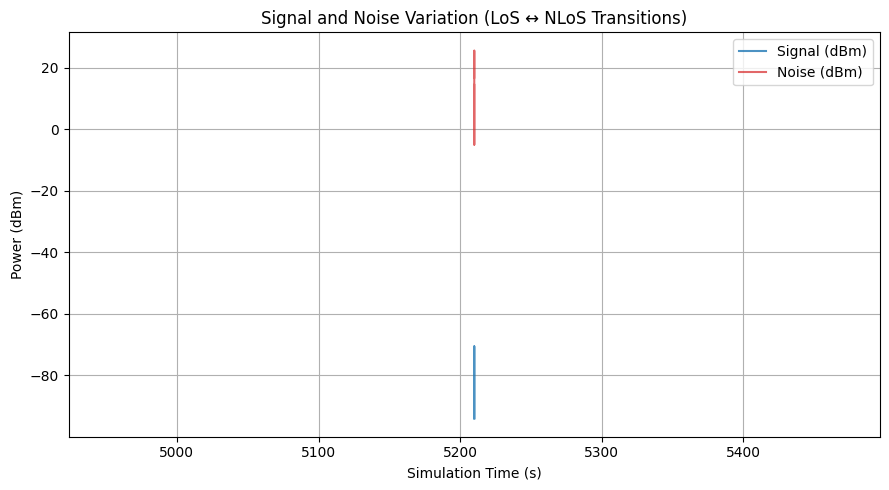

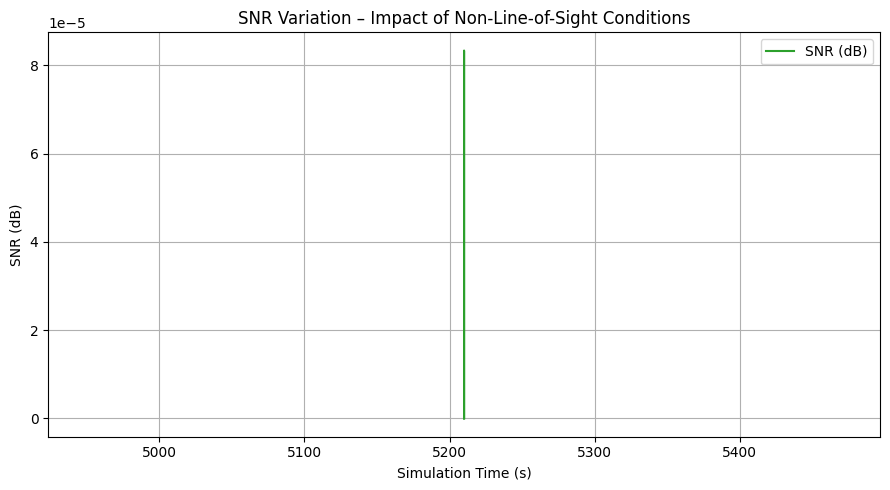

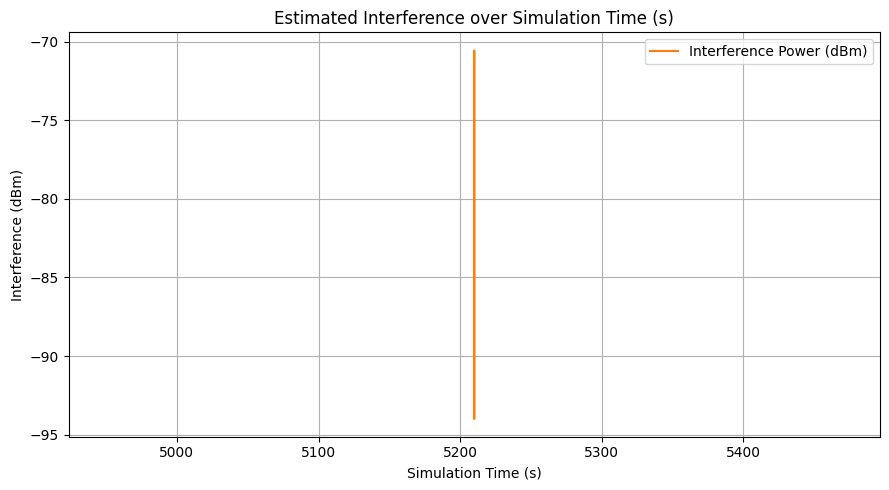

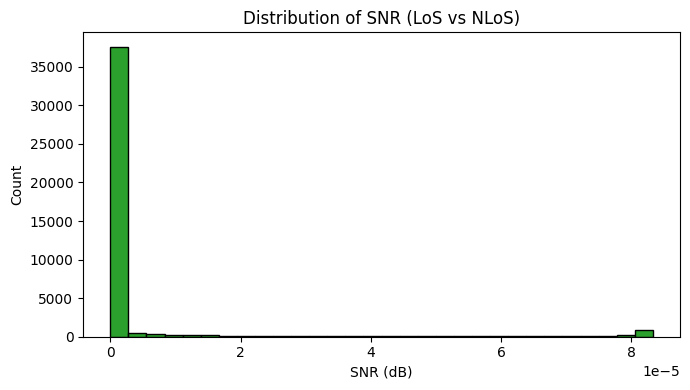

📉 Estimated NLoS fraction: 100.0% of samples (SNR < 20 dB)


,time_s,channel_MHz,Modulation,ConstellationSize,PhyRate_Mbps,signal_dBm,noise_dBm,SNR_dB,BER,RandSeed,RunDateTime,time_delta,SimDateTime,Interference_dBm
0,5210,OFDM,2,6.0,-77.102540,-93.965985,16.863445,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
1,5210,OFDM,2,6.0,-72.502153,-93.965985,21.463832,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
2,5210,OFDM,2,6.0,-73.761263,-93.965985,20.204723,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
3,5210,OFDM,2,6.0,-79.613417,-93.965985,14.352568,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
4,5210,OFDM,2,6.0,-81.601945,-93.965985,12.364040,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41987,5210,OFDM,2,6.0,-76.730844,-93.965985,17.235141,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
41988,5210,OFDM,2,6.0,-77.995783,-93.965985,15.970202,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
41989,5210,OFDM,2,6.0,-78.698569,-93.965985,15.267416,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985
41990,5210,OFDM,2,6.0,-79.206813,-93.965985,14.759173,2.225074e-308,-3076.52656,12345,NaT,0 days 01:26:50,NaT,-93.965985


In [75]:
visualize_nlos_effect(modulation_df)

In [ ]:
# ============================================================
# 📈 Throughput vs Node Density (Sorted + Averaged)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

def plot_avg_throughput_sorted(df):
    """
    Plots average throughput vs node density, automatically averaging
    duplicate NodeDensity values and sorting them ascending.
    Works with outputs from -nodedensity.csv.
    """

    # --- Check required columns ---
    if "NodeDensity" not in df.columns or "TotalThroughput(Mbps)" not in df.columns:
        raise ValueError("❌ Required columns not found in DataFrame.")

    # --- Group by NodeDensity and average ---
    grouped = (
        df.groupby("NodeDensity", as_index=False)["TotalThroughput(Mbps)"]
        .mean()
        .sort_values("NodeDensity")
        .reset_index(drop=True)
    )

    # --- Plot ---
    plt.figure(figsize=(8,5))
    plt.plot(grouped["NodeDensity"], grouped["TotalThroughput(Mbps)"],
             marker="o", linewidth=2, color="tab:blue")
    plt.xlabel("Node Density (# of Active Stations)")
    plt.ylabel("Average Throughput (Mbps)")
    plt.title("Throughput vs Node Density (Averaged & Sorted)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Return processed DataFrame (for thesis tables or verification) ---
    return grouped


In [84]:
plot_avg_throughput_sorted(nodedensity_df)

ValueError: ❌ Required columns not found in DataFrame.